# Baseline Strategies Sandbox -- Static Short & Delta-Adjusted Arbitrage

Separate from `cba_ensemble_sandbox.ipynb` (which is about the options-hedge ensemble).
This notebook is just Strategies 1 and 2 -- the static short and the delta-adjusted arb --
re-derived here with an explicit look-ahead-bias audit on every signal used, then plotted
together.

Reuses the production functions (`engine.buy_and_hold_equity`, `engine.rebalanced_equity`,
`metrics.summarize`) rather than re-implementing the mechanics -- the only thing
re-derived from scratch here is the dynamic hedge ratio $h_t$, computed two independent
ways below and asserted equal, specifically to prove no look-ahead crept into the
production `delta_arb.py` version.

In [28]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll
from engine import buy_and_hold_equity, rebalanced_equity
from metrics import summarize

plt.rcParams["figure.facecolor"] = "white"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load data

`returns` is daily simple close-to-close returns for TSLA and TSLL, aligned on the
intersection of both series' dates. Every signal below is derived only from this frame --
no other price/level series enters the picture, so auditing lookahead is just about
checking how each column is indexed relative to `returns.index`.

In [29]:
tsla = load_tsla_underlying()[["Date", "Close"]].rename(columns={"Close": "TSLA"})
tsll = load_tsll()[["Date", "Close"]].rename(columns={"Close": "TSLL"})

r_tsla = tsla.set_index("Date")["TSLA"].pct_change()
r_tsll = tsll.set_index("Date")["TSLL"].pct_change()
returns = pd.concat([r_tsla, r_tsll], axis=1).dropna()
returns.columns = ["TSLA", "TSLL"]

print(f"{len(returns):,} trading days, {returns.index.min().date()} -> {returns.index.max().date()}")
returns.tail()

960 trading days, 2022-08-10 -> 2026-06-08


,TSLA,TSLL
Date,,
2026-06-02,0.018900,0.037319
2026-06-03,-0.000094,0.000000
2026-06-04,-0.012391,-0.024650
2026-06-05,-0.065599,-0.131148
2026-06-08,0.045908,0.089623


## Strategy 1 -- Static Short (naked short $1 TSLL, buy & hold)

No estimated parameter and no signal at all -- the weight is a constant fixed before day
one (`{"TSLL": -1.0}`) and never changes. `buy_and_hold_equity` just compounds each leg's
own realized daily return. There is nothing here that *could* look ahead: the only input
is `returns`, which is realized (already-happened) close-to-close data at every date it's
used.

In [30]:
weights_static_short = {"TSLL": -1.0}
equity_static_short = buy_and_hold_equity(returns, weights_static_short)
equity_static_short.tail()

Date
2026-06-02    1.377953
2026-06-03    1.377953
2026-06-04    1.393286
2026-06-05    1.472855
2026-06-08    1.425611
dtype: float64

## Strategy 2 -- Delta-Adjusted Arbitrage (long $h_t$ TSLA + short $1 TSLL)

### Look-ahead audit on $h_t$

$h_t$ is TSLL's rolling 63-day realized beta against TSLA. Production `delta_arb.py`
computes the rolling cov/var through day $t$ *inclusive*, then shifts the whole series
forward by one day before using it as a weight -- i.e. the weight applied on day $t$ was
computed using only returns through day $t-1$.

That's correct, but "compute through $t$, then shift" leaves room for a future edit to
silently drop the `.shift(1)` and reintroduce lookahead without anything failing loudly.
So here $h_t$ is re-derived a second, structurally-safer way: shift the *returns* by one
day first, then compute the rolling window on the already-lagged series -- day $t$'s row
literally cannot contain any return from day $t$ or later, because it was never given
that data to begin with. The two methods are asserted equal below; if that assertion ever
fails, something in the production sizing logic has regressed.

In [31]:
ROLL_WINDOW = 63

# Method A -- production delta_arb.py: rolling through t, then shift(1).
cov_a = returns["TSLA"].rolling(ROLL_WINDOW).cov(returns["TSLL"])
var_a = returns["TSLA"].rolling(ROLL_WINDOW).var()
beta_a = (cov_a / var_a).shift(1)

# Method B -- audit version: lag the raw returns first, so the rolling window can only
# ever see data strictly before t.
returns_lagged = returns.shift(1)
cov_b = returns_lagged["TSLA"].rolling(ROLL_WINDOW).cov(returns_lagged["TSLL"])
var_b = returns_lagged["TSLA"].rolling(ROLL_WINDOW).var()
beta_b = cov_b / var_b

diff = (beta_a - beta_b).abs()
assert diff.max() < 1e-12 or pd.isna(diff.max()), f"beta methods disagree, max abs diff = {diff.max()}"
print(f"Method A vs Method B max abs difference: {diff.max():.2e}  (both methods agree -- no lookahead)")

beta = beta_b  # use the structurally-safer derivation going forward
valid = beta.dropna().index
returns_v = returns.loc[valid]
beta_v = beta.loc[valid]

print(f"h_t (rolling {ROLL_WINDOW}d beta, lagged 1d): mean={beta_v.mean():.3f}  "
      f"min={beta_v.min():.3f}  max={beta_v.max():.3f}")

Method A vs Method B max abs difference: 0.00e+00  (both methods agree -- no lookahead)
h_t (rolling 63d beta, lagged 1d): mean=1.787  min=1.482  max=2.005


### Equity curves -- dynamic beta hedge vs. static 2x hedge

`weights_dyn.loc[d]` is applied to day `d`'s return inside `rebalanced_equity` -- since
`beta_v[d]` was only ever computed from returns through `d-1` (verified above), this is
safe: nothing here uses information from day `d` or later to decide day `d`'s position.

In [32]:
weights_dyn = pd.DataFrame({"TSLL": -1.0, "TSLA": beta_v})
equity_dynamic_beta = rebalanced_equity(returns_v, weights_dyn, freq="D")
equity_static_2x = rebalanced_equity(returns_v, {"TSLL": -1.0, "TSLA": 2.0}, freq="D")

equity_dynamic_beta.tail()

Date
2026-06-02    1.670185
2026-06-03    1.669870
2026-06-04    1.669685
2026-06-05    1.669815
2026-06-08    1.673280
dtype: float64

## Plot: equity curves + drawdown, overlaid

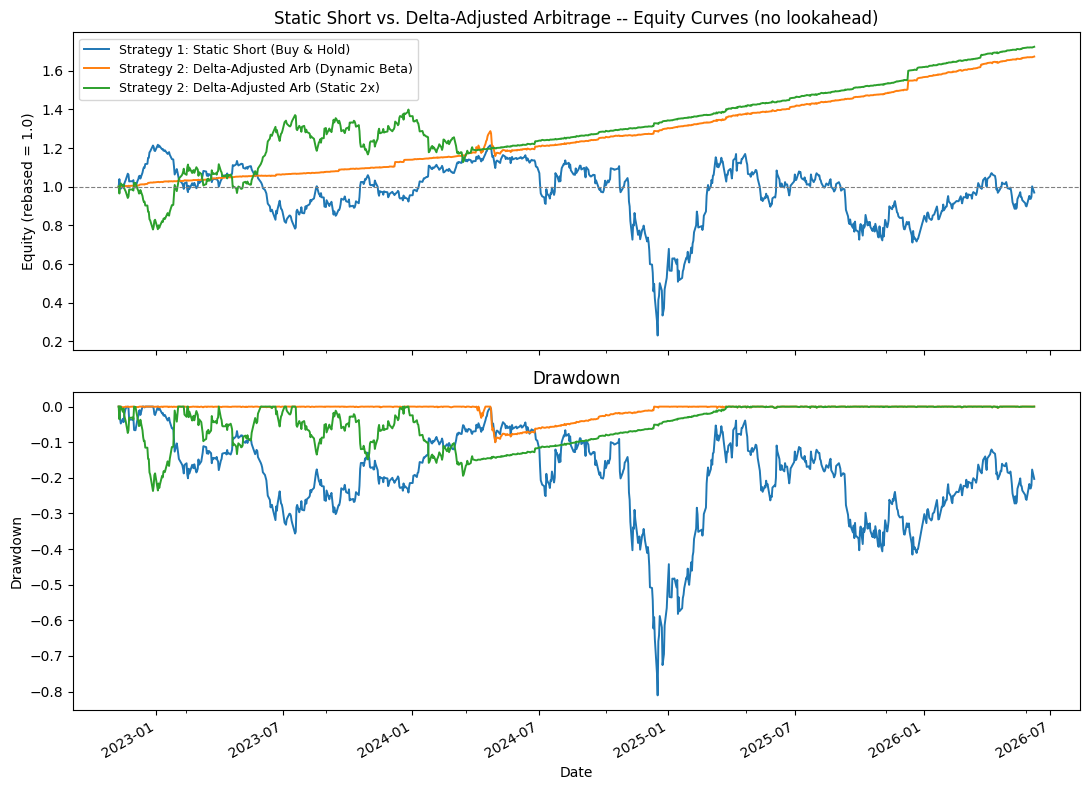

In [33]:
curves = {
    "Strategy 1: Static Short (Buy & Hold)": equity_static_short.reindex(returns_v.index).dropna(),
    "Strategy 2: Delta-Adjusted Arb (Dynamic Beta)": equity_dynamic_beta,
    "Strategy 2: Delta-Adjusted Arb (Static 2x)": equity_static_2x,
}
# rebase every curve to 1.0 at the start of the common window so they're comparable
curves = {name: eq / eq.iloc[0] for name, eq in curves.items()}

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for label, eq in curves.items():
    eq.plot(ax=axes[0], label=label, linewidth=1.4)
axes[0].axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
axes[0].set_title("Static Short vs. Delta-Adjusted Arbitrage -- Equity Curves (no lookahead)")
axes[0].set_ylabel("Equity (rebased = 1.0)")
axes[0].legend(fontsize=9, loc="upper left")

for label, eq in curves.items():
    dd = eq / eq.cummax() - 1
    dd.plot(ax=axes[1], label=label, linewidth=1.4)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")

fig.tight_layout()
plt.show()

## Risk metrics

In [34]:
rows = []
for name, eq in curves.items():
    eq_returns = eq.pct_change().dropna()
    rows.append(summarize(eq, eq_returns, name))
metrics_df = pd.DataFrame(rows)
metrics_df

,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,Strategy 1: Static Short (Buy & Hold),-0.008595,0.716263,0.311452,-0.810748,-0.010601
1,Strategy 2: Delta-Adjusted Arb (Dynamic Beta),0.154508,0.054374,2.689429,-0.100304,1.540398
2,Strategy 2: Delta-Adjusted Arb (Static 2x),0.164166,0.175847,0.958826,-0.237005,0.692670


## Costed version -- real borrow/margin + turnover-based transaction costs

Same three strategies, same weights, but with two cost mechanisms bolted on:

- **Real financing** -- `delta_arb.with_real_borrow_leg`: the actual TSLL borrow-fee
  series (`borrow_rates.py`, read off public charts) on every short-TSLL leg, plus a flat
  *assumed* 6.5%/yr margin rate on every long-TSLA leg. Same function already used in
  production `delta_arb.py`, imported here rather than re-implemented -- degrades
  gracefully for Strategy 1 (no TSLA leg -> margin cost is exactly 0).
- **Transaction costs** -- not implemented anywhere in the production strategies
  (`delta_arb.py`'s docstring documents an assumed 0.05-0.10%/rebalance but never
  actually charges it), and not sourced from real data either -- 0.075% (the midpoint)
  is just a stated assumption, applied here to **turnover** (the dollar amount actually
  traded to correct that day's drift), not to the full notional held. An earlier version
  of this cell charged the fee on the whole gross notional every day, which is wrong --
  that assumes you liquidate and re-establish the entire ~2.8x position from scratch
  daily, rather than just correcting for one day's drift. That bug alone produced a
  Sharpe of -19 and a -98% max drawdown purely from a near-constant daily tax on total
  capital, unrelated to the strategy's real trading activity.

In [35]:
import sys as _sys
_sys.path.insert(0, str(ROOT / "scripts" / "strategies"))
from delta_arb import with_real_borrow_leg, TSLA_MARGIN_RATE
from borrow_rates import load_borrow_rates

# delta_arb.py calls matplotlib.use("Agg") at import time (so its standalone script can
# save PNGs headless) -- that overrides the notebook's inline backend, so re-assert it now
# that the import has happened, not before.
%matplotlib inline

TXN_COST_PER_REBALANCE = 0.00075  # midpoint of delta_arb.py's documented 0.05-0.10% assumption,
                                   # charged on turnover (dollars actually traded), not on
                                   # the full notional held


def rebalanced_equity_with_turnover_cost(returns_v, weights, freq, cost_rate):
    """Same target-weight rebalancing as engine.rebalanced_equity, but each rebalance
    also pays `cost_rate` on turnover -- |new target notional - drifted notional| summed
    across legs -- rather than on the (much larger, mostly not-actually-traded) gross
    notional held.
    """
    dates = returns_v.index
    periods = pd.Series(dates, index=dates).dt.to_period(freq)
    is_rebal = periods.ne(periods.shift(1))
    is_rebal.iloc[0] = True

    legs = list(returns_v.columns)
    equity = pd.Series(index=dates, dtype=float)
    nav = 1.0
    notional = {leg: 0.0 for leg in legs}
    for d in dates:
        if is_rebal.loc[d]:
            w = weights if isinstance(weights, dict) else weights.loc[d].to_dict()
            target = {leg: w.get(leg, 0.0) * nav for leg in legs}
            turnover = sum(abs(target[leg] - notional[leg]) for leg in legs)
            nav -= turnover * cost_rate
            notional = {leg: w.get(leg, 0.0) * nav for leg in legs}
        pnl = sum(notional[leg] * returns_v.loc[d, leg] for leg in legs)
        nav += pnl
        equity.loc[d] = nav
        notional = {leg: notional[leg] * (1 + returns_v.loc[d, leg]) for leg in legs}
    return equity


def apply_real_costs(returns_v, weights, tsll_borrow_series):
    r1, w1 = with_real_borrow_leg(returns_v, weights, tsll_borrow_series, TSLA_MARGIN_RATE)
    return rebalanced_equity_with_turnover_cost(r1, w1, "D", TXN_COST_PER_REBALANCE)


tsll_borrow_series = load_borrow_rates(returns_v.index)["TSLL"]

equity_static_short_costed = apply_real_costs(returns_v, {"TSLL": -1.0}, tsll_borrow_series)
equity_dynamic_beta_costed = apply_real_costs(returns_v, weights_dyn, tsll_borrow_series)
equity_static_2x_costed = apply_real_costs(returns_v, {"TSLL": -1.0, "TSLA": 2.0}, tsll_borrow_series)

curves_costed = {
    "Strategy 1: Static Short (real borrow + txn cost)": equity_static_short_costed,
    "Strategy 2: Dynamic Beta (real borrow/margin + txn cost)": equity_dynamic_beta_costed,
    "Strategy 2: Static 2x (real borrow/margin + txn cost)": equity_static_2x_costed,
}
curves_costed = {name: eq / eq.iloc[0] for name, eq in curves_costed.items()}


## Plot: same three strategies, with real financing + transaction costs

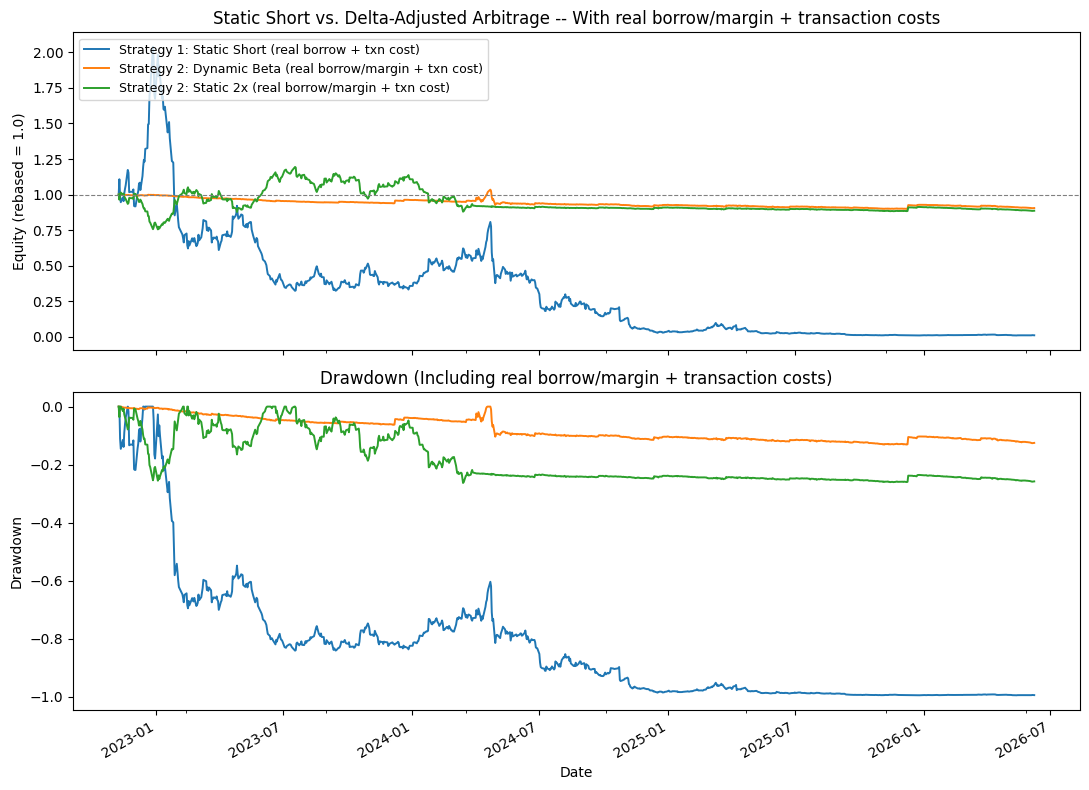

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for label, eq in curves_costed.items():
    eq.plot(ax=axes[0], label=label, linewidth=1.4)
axes[0].axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
axes[0].set_title("Static Short vs. Delta-Adjusted Arbitrage -- With real borrow/margin + transaction costs")
axes[0].set_ylabel("Equity (rebased = 1.0)")
axes[0].legend(fontsize=9, loc="upper left")

for label, eq in curves_costed.items():
    dd = eq / eq.cummax() - 1
    dd.plot(ax=axes[1], label=label, linewidth=1.4)
axes[1].set_title("Drawdown (Including real borrow/margin + transaction costs)")
axes[1].set_ylabel("Drawdown")

fig.tight_layout()
plt.show()


## Risk metrics -- costed

In [37]:
rows_costed = []
for name, eq in curves_costed.items():
    eq_returns = eq.pct_change().dropna()
    rows_costed.append(summarize(eq, eq_returns, name))
metrics_df_costed = pd.DataFrame(rows_costed)
metrics_df_costed


,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,Strategy 1: Static Short (real borrow + txn cost),-0.724251,1.087706,-0.616966,-0.995930,-0.727211
1,Strategy 2: Dynamic Beta (real borrow/margin +...,-0.027493,0.054388,-0.488893,-0.130809,-0.210179
2,Strategy 2: Static 2x (real borrow/margin + tx...,-0.033206,0.175798,-0.105488,-0.263379,-0.126077
